In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def to_pixel_arrays(my_df, activation_threshold=0, x_dimension=16, y_dimension=16):
    pixel_arrays_flat = my_df.to_numpy() 
    num_activated_pixels = np.sum((pixel_arrays_flat > activation_threshold), axis=1)
    pixel_arrays = pixel_arrays_flat.reshape(-1, y_dimension, x_dimension) 
    x_sizes = np.sum(np.any(pixel_arrays > activation_threshold, axis=1), axis=1) 
    y_sizes = np.sum(np.any(pixel_arrays > activation_threshold, axis=2), axis=1)
    
    return pixel_arrays_flat, pixel_arrays, num_activated_pixels, x_sizes, y_sizes

In [3]:
def to_df(file_list):    
    dfs = []
    for file in file_list:
        try:
            df = pd.read_parquet(file)
            dfs.append(df)
        except Exception as e:
            print(f"Failed to read {file}: {e}")
    
    my_df = pd.concat(dfs, ignore_index=True)
    return my_df

In [4]:
labels_df = to_df(glob.glob('/data/dajiang/smart-pixels/largerWindowPreliminary/dataset_3s_32x32_50x12P5_parquets/unflipped/labels*.parquet'))
recon2D_df = to_df(glob.glob('/data/dajiang/smart-pixels/largerWindowPreliminary/dataset_3s_32x32_50x12P5_parquets/unflipped/recon2D*.parquet'))

In [5]:
labels_df_2 = to_df(glob.glob('/data/dajiang/smart-pixels/dataset_3s/dataset_3s_50x12P5_parquets/unflipped/labels*.parquet'))
recon2D_df_2 = to_df(glob.glob('/data/dajiang/smart-pixels/dataset_3s/dataset_3s_50x12P5_parquets/unflipped/recon2D*.parquet'))

In [7]:
labels_df_3 = to_df(glob.glob('/data/dajiang/smart-pixels/largerWindowPreliminary/dataset_3s_32x32_50x12P5_-7_7_offsets_parquets/unflipped/labels*.parquet'))
recon2D_df_3 = to_df(glob.glob('/data/dajiang/smart-pixels/largerWindowPreliminary/dataset_3s_32x32_50x12P5_-7_7_offsets_parquets/unflipped/recon2D*uncentered*.parquet'))

In [8]:
f = open('plots/dataset_3s_32x32_plots/event_stats.txt', 'w')
f.write(f'For dataset_3s_32x32_50x12P5_parquets: \n')
f.write(f'Total number events: {len(labels_df)} events\n')
f.write(f'Number of "original_atEdge == True" events: {len(labels_df[labels_df["original_atEdge"]==True])} events\n')
f.write(f'Number of "chargeOriginal_atEdge >= 50" events: {len(labels_df[labels_df["chargeOriginal_atEdge"]>=50])} events\n')
f.write(f'Number of "original_atEdge == True and chargeOriginal_atEdge >= 50" events: {len(labels_df[(labels_df["original_atEdge"] == True) & (labels_df["chargeOriginal_atEdge"] >= 50)])} events\n')
f.write(f'Number of "original_atEdge == False and chargeOriginal_atEdge >= 50" events: {len(labels_df[(labels_df["original_atEdge"] == False) & (labels_df["chargeOriginal_atEdge"] >= 50)])} events\n')
f.write('\n')
f.write(f'For dataset_3s_32x32_50x12P5_-7_7_offset_parquets: \n' )
f.write(f'Total number events: {len(labels_df_3)} events\n')
f.write(f'Number of "original_atEdge == True" events: {len(labels_df_3[labels_df_3["original_atEdge"]==True])} events\n')
f.write(f'Number of "chargeOriginal_atEdge >= 50" events: {len(labels_df_3[labels_df_3["chargeOriginal_atEdge"]>=50])} events\n')
f.write(f'Number of "original_atEdge == True and chargeOriginal_atEdge >= 50" events: {len(labels_df_3[(labels_df_3["original_atEdge"] == True) & (labels_df_3["chargeOriginal_atEdge"] >= 50)])} events\n')
f.write(f'Number of "original_atEdge == False and chargeOriginal_atEdge >= 50" events: {len(labels_df_3[(labels_df_3["original_atEdge"] == False) & (labels_df_3["chargeOriginal_atEdge"] >= 50)])} events\n')
f.write(f'Number of "uncentered_atEdge == True" events: {len(labels_df_3[labels_df_3["uncentered_atEdge"]==True])} events\n')
f.write(f'Number of "chargeUncentered_atEdge >= 50" events: {len(labels_df_3[labels_df_3["chargeUncentered_atEdge"]>=50])} events\n')
f.write(f'Number of "uncentered_atEdge == True and chargeUncentered_atEdge >= 50" events: {len(labels_df_3[(labels_df_3["uncentered_atEdge"] == True) & (labels_df_3["chargeUncentered_atEdge"] >= 50)])} events\n')
f.write(f'Number of "uncentered_atEdge == False and chargeUncentered_atEdge >= 50" events: {len(labels_df_3[(labels_df_3["uncentered_atEdge"] == False) & (labels_df_3["chargeUncentered_atEdge"] >= 50)])} events\n')
f.close()

In [27]:
labels_df

,x-entry,y-entry,z-entry,n_x,n_y,n_z,number_eh_pairs,y-local,pt,cotAlpha,cotBeta,y-midplane,x-midplane,original_atEdge,chargeOriginal_atEdge,nPixOriginalAbove1e_atEdge
0,119.335152,-136.762131,100.0,-0.377359,1.342717,-0.536464,19914.0,69.392899,-1.44592,0.703419,-2.502902,-11.617014,84.164199,True,1723.0,1
1,132.755951,-73.295898,100.0,-1.617915,3.205914,-2.072865,15123.0,47.789902,3.81768,0.780521,-1.546610,4.034608,93.729893,False,0.0,0
2,-206.884003,-127.692001,100.0,4.734690,4.662470,-1.653393,28749.0,82.242500,-4.94695,-2.863620,-2.819941,13.305028,-63.702981,True,3954.0,3
3,-399.666321,89.406464,100.0,15.856865,-4.153361,-2.414099,55343.0,-51.422001,4.80398,-6.568440,1.720460,3.383459,-71.244309,True,13015.0,6
4,-19.548094,-153.385483,100.0,1.202412,2.710343,-1.053878,18416.0,74.785400,-2.90803,-1.140940,-2.571781,-24.796453,37.498927,True,1854.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1971812,-217.275360,-168.400635,100.0,2.886779,4.119564,-1.220651,71697.0,96.890800,-4.29660,-2.364950,-3.374891,0.343912,-99.027843,True,3516.0,2
1971813,-518.593689,-142.828171,100.0,14.158907,4.555347,-1.662620,83103.0,81.308098,-4.84928,-8.516021,-2.739861,-5.835142,-92.792634,True,16978.0,5
1971814,-397.187927,189.001923,100.0,6.223044,-3.425467,-1.007722,53117.0,-95.068901,3.57062,-6.175358,3.399218,19.041011,-88.420033,True,4502.0,3
1971815,81.233910,-118.465607,100.0,-3.058618,2.942421,-1.310597,34499.0,69.149498,3.22110,2.333759,-2.245100,-6.210619,-35.454057,True,2683.0,1


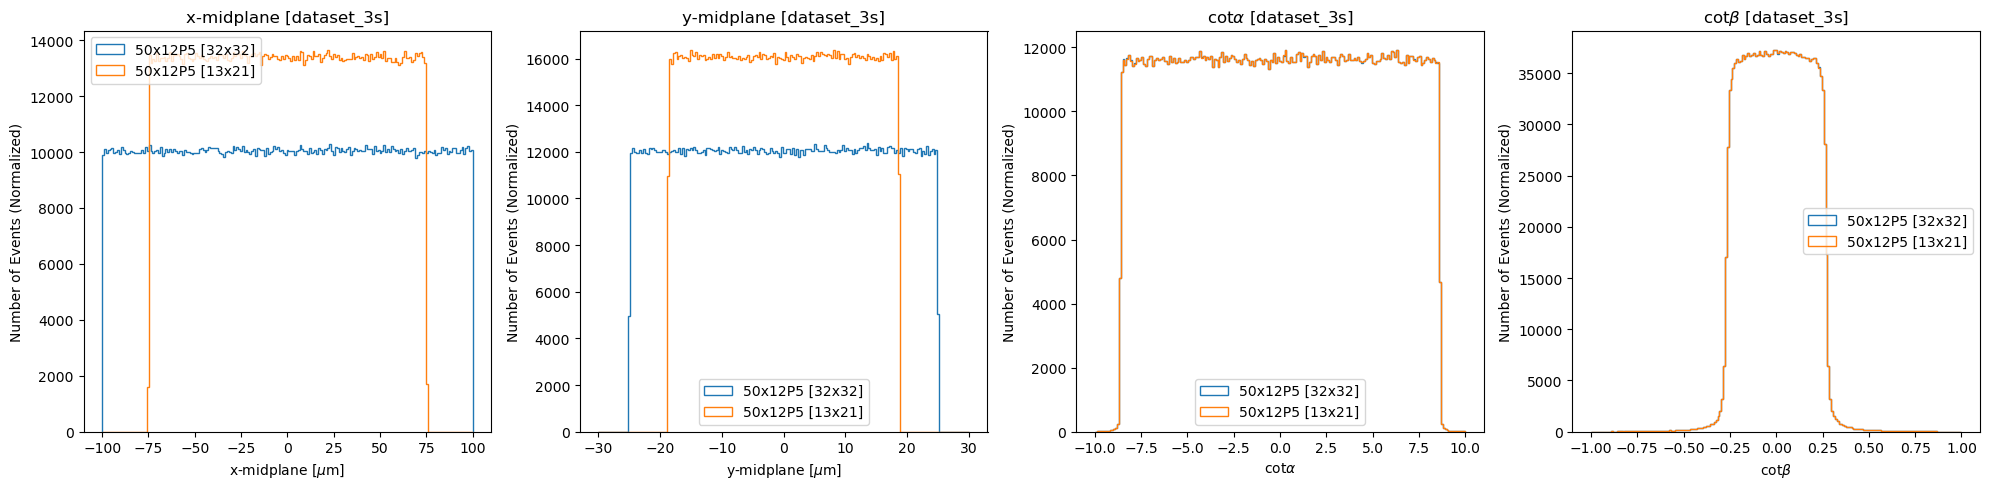

In [25]:
fig, ax = plt.subplots(1,4, figsize=(20,5))

ax[0].hist(labels_df['x-midplane'], bins=np.linspace(-100,100,200), histtype='step', label='50x12P5 [32x32]')
ax[0].hist(labels_df_2['x-midplane'], bins=np.linspace(-100,100,200), histtype='step', label='50x12P5 [13x21]')
#ax[0].hist(labels_df_3['x-midplane'], bins=np.linspace(-450,450,200), histtype='step', label='50x12P5 [32x32], offset')
ax[0].set_title(r'x-midplane [dataset_3s]')
ax[0].set_xlabel(r'x-midplane [$\mu$m]')
ax[0].set_ylabel(r'Number of Events (Normalized)')
ax[0].legend(loc='upper left')

ax[1].hist(labels_df['y-midplane'], bins=np.linspace(-30,30,200), histtype='step', label='50x12P5 [32x32]')
ax[1].hist(labels_df_2['y-midplane'], bins=np.linspace(-30,30,200), histtype='step', label='50x12P5 [13x21]')
#ax[1].hist(labels_df_3['y-midplane'], bins=np.linspace(-150,150,200), histtype='step', label='50x12P5 [32x32], offset')

ax[1].set_title(r'y-midplane [dataset_3s]')
ax[1].set_xlabel(r'y-midplane [$\mu$m]')
ax[1].set_ylabel(r'Number of Events (Normalized)')
ax[1].legend()

ax[2].hist(labels_df['cotAlpha'], bins=np.linspace(-10,10,200), histtype='step', label='50x12P5 [32x32]')
ax[2].hist(labels_df_2['cotAlpha'], bins=np.linspace(-10,10,200), histtype='step', label='50x12P5 [13x21]')
#ax[2].hist(labels_df_3['cotAlpha'], bins=np.linspace(-10,10,200), histtype='step', label='50x12P5 [32x32], offset')
ax[2].set_title(r'cot$\alpha$ [dataset_3s]')
ax[2].set_xlabel(r'cot$\alpha$')
ax[2].set_ylabel(r'Number of Events (Normalized)')
ax[2].legend()

ax[3].hist(labels_df['cotBeta'], bins=np.linspace(-1,1,200), histtype='step', label='50x12P5 [32x32]')
ax[3].hist(labels_df_2['cotBeta'], bins=np.linspace(-1,1,200), histtype='step', label='50x12P5 [13x21]')
#ax[3].hist(labels_df_3['cotBeta'], bins=np.linspace(-1,1,200), histtype='step', label='50x12P5 [32x32], offset')
ax[3].set_title(r'cot$\beta$ [dataset_3s]')
ax[3].set_xlabel(r'cot$\beta$')
ax[3].set_ylabel(r'Number of Events (Normalized)')
ax[3].legend()

fig.tight_layout()
fig.savefig('plots/dataset_3s_32x32_plots/50x12P5_labels_vs_13x21.png', dpi=300)
fig.show()

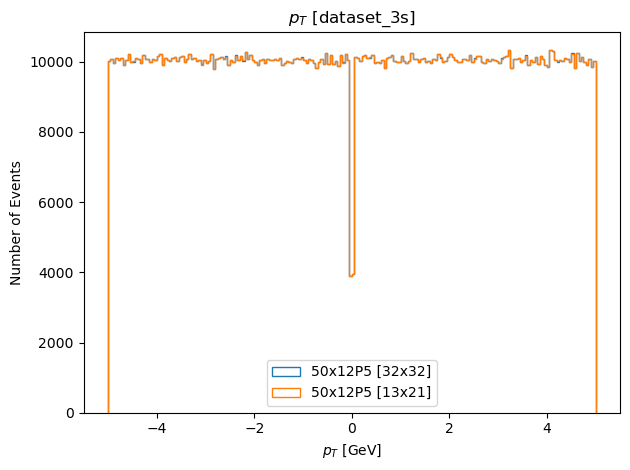

In [12]:
fig, ax = plt.subplots()

ax.hist(labels_df['pt'], bins=200, histtype='step', label='50x12P5 [32x32]')
ax.hist(labels_df_2['pt'], bins=200, histtype='step', label='50x12P5 [13x21]')
#ax.hist(labels_df_3['pt'], bins=200, histtype='step', label='50x12P5 [32x32], offset')
ax.legend()
ax.set_title(r'$p_T$ [dataset_3s]')
ax.set_xlabel(r'$p_T$ [GeV]')
ax.set_ylabel(r'Number of Events')
fig.tight_layout()
fig.savefig('plots/dataset_3s_32x32_plots/50x12P5_pt_vs_13x21.png', dpi=300)
fig.show()

In [30]:
recon2D_df

,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,567.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1245.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1971812,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1971813,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1971814,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1971815,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1828.0,2941.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
pixel_arrays_flat, pixel_arrays, num_activated_pixels, x_sizes, y_sizes = to_pixel_arrays(recon2D_df, 400, x_dimension=32, y_dimension=32)

In [14]:
pixel_arrays_flat2, pixel_arrays2, num_activated_pixels2, x_sizes2, y_sizes2 = to_pixel_arrays(recon2D_df_2, 400, x_dimension=21, y_dimension=13)

In [15]:
pixel_arrays_flat3, pixel_arrays3, num_activated_pixels3, x_sizes3, y_sizes3 = to_pixel_arrays(recon2D_df_3, 400, x_dimension=32, y_dimension=32)

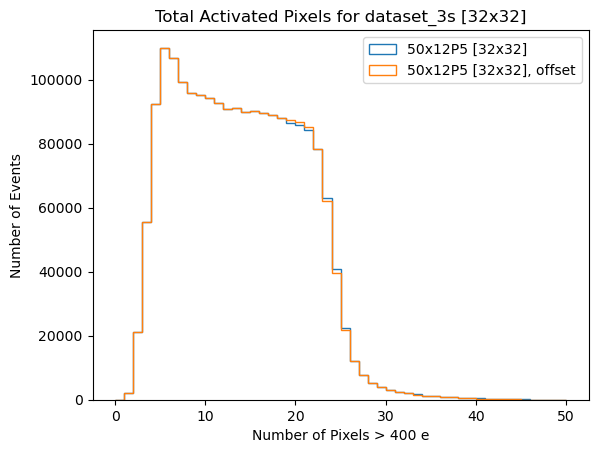

In [17]:
fig, ax = plt.subplots()

ax.hist(num_activated_pixels, bins=np.linspace(0,50,51), histtype='step', label='50x12P5 [32x32]')
#ax.hist(num_activated_pixels2, bins=np.linspace(0,50,51), histtype='step', label='50x12P5 [13x21]')
ax.hist(num_activated_pixels3, bins=np.linspace(0,50,51), histtype='step', label='50x12P5 [32x32], offset')

ax.legend()
ax.set_xlabel('Number of Pixels > 400 e')
ax.set_ylabel('Number of Events')
ax.set_title('Total Activated Pixels for dataset_3s [32x32]')
fig.savefig('plots/dataset_3s_32x32_plots/50x12P5_num_activated_pixels_vs_offset.png', dpi=300)
fig.show()

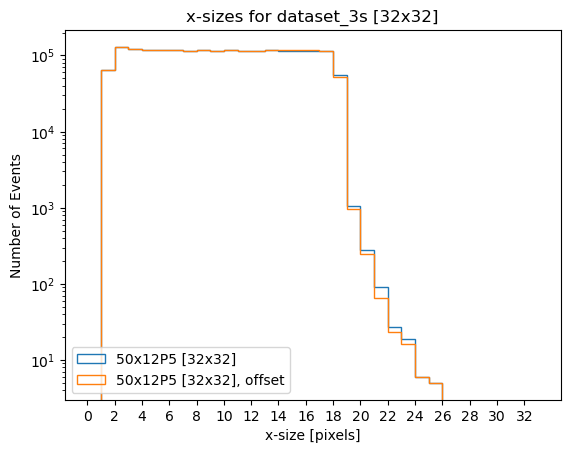

In [19]:
fig, ax = plt.subplots()

ax.hist(x_sizes, bins=np.linspace(0,33,34), histtype='step', label='50x12P5 [32x32]')
#ax.hist(x_sizes2, bins=np.linspace(0,33,34), histtype='step', label='50x12P5 [13x21]')
ax.hist(x_sizes3, bins=np.linspace(0,33,34), histtype='step', label='50x12P5 [32x32], offset')

ax.legend()
ax.set_yscale('log')
ax.set_xticks(np.arange(0,34,2))
ax.set_xlabel('x-size [pixels]')
ax.set_ylabel('Number of Events')
ax.set_title('x-sizes for dataset_3s [32x32]')
fig.savefig('plots/dataset_3s_32x32_plots/50x12P5_x_size_vs_offset.png', dpi=300)
fig.show()

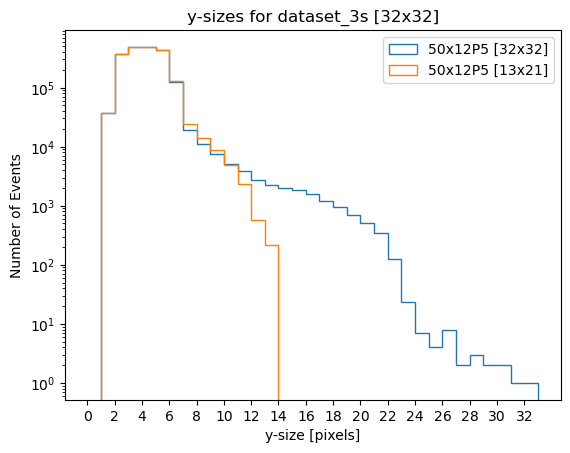

In [21]:
fig, ax = plt.subplots()

ax.hist(y_sizes, bins=np.linspace(0,33,34), histtype='step', label='50x12P5 [32x32]')
ax.hist(y_sizes2, bins=np.linspace(0,33,34), histtype='step', label='50x12P5 [13x21]')
#ax.hist(y_sizes3, bins=np.linspace(0,33,34), histtype='step', label='50x12P5 [32x32], offset')

ax.set_yscale('log')
ax.legend()
ax.set_xticks(np.arange(0,34,2))
ax.set_xlabel('y-size [pixels]')
ax.set_ylabel('Number of Events')
ax.set_title('y-sizes for dataset_3s [32x32]')
fig.savefig('plots/dataset_3s_32x32_plots/50x12P5_y_size_vs_13x21.png', dpi=300)
fig.show()